In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Sin GPU")

True
Tesla T4


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/content/drive/MyDrive/Trabajo")
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_PATH:", SRC_PATH)
print("Existe PROJECT_ROOT:", PROJECT_ROOT.exists())
print("Existe SRC_PATH:", SRC_PATH.exists())

PROJECT_ROOT: /content/drive/MyDrive/Trabajo
SRC_PATH: /content/drive/MyDrive/Trabajo/src
Existe PROJECT_ROOT: True
Existe SRC_PATH: True


In [4]:
import zipfile
from pathlib import Path

zip_path = PROJECT_ROOT / "datasets-001.zip"

LOCAL_DATA_ROOT = Path("/content/datasets")
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(LOCAL_DATA_ROOT)

print("Descompresión terminada.")
for p in LOCAL_DATA_ROOT.iterdir():
    print(p)

Descompresión terminada.
/content/datasets/datasets


In [5]:
inner_root = LOCAL_DATA_ROOT / "datasets"
print(inner_root)
print(inner_root.exists())

for p in inner_root.iterdir():
    print(p)

/content/datasets/datasets
True
/content/datasets/datasets/EuroSATallBands
/content/datasets/datasets/EuroSAT


In [6]:
DATA_DIR = LOCAL_DATA_ROOT / "datasets" / "EuroSAT"

print(DATA_DIR)
print(DATA_DIR.exists())
print([p.name for p in DATA_DIR.iterdir()][:20])

/content/datasets/datasets/EuroSAT
True
['test.csv', 'Pasture', 'Industrial', 'Highway', 'SeaLake', 'River', 'validation.csv', 'train.csv', 'Forest', 'PermanentCrop', 'HerbaceousVegetation', 'AnnualCrop', 'label_map.json', 'Residential']


# 02 - Modelos preentrenados y fine-tuning

En este notebook se evalúa el uso de modelos preentrenados para la clasificación de imágenes del dataset EuroSAT. El objetivo es comparar distintas estrategias de transferencia de aprendizaje utilizando la misma partición de datos empleada en el bloque de CNN desde cero.

Se analizarán tres configuraciones principales:

1. ResNet18 sin preentrenamiento  
2. ResNet18 preentrenado con capas congeladas  
3. ResNet18 preentrenado con fine-tuning  

Posteriormente, se comparará la mejor variante preentrenada con la mejor CNN desde cero obtenida en el bloque anterior.

In [75]:
import sys
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

plt.style.use("default")
sns.set_style("whitegrid")

## Importando funciones compartidas

In [76]:
from data_utils import (
    set_seed,
    load_splits,
    create_dataloaders_from_splits
)

## Semilla y dispositivo

In [77]:
SEED = 42
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", DEVICE)

Dispositivo en uso: cuda


## Cargar los splits del subconjunto balanceado

In [78]:
split_info = load_splits()

print("Número de muestras en train:", len(split_info["train_indices"]))
print("Número de muestras en val:", len(split_info["val_indices"]))
print("Número de muestras en test:", len(split_info["test_indices"]))
print("Número de clases:", len(split_info["class_names"]))
print("Clases:", split_info["class_names"])

Número de muestras en train: 6999
Número de muestras en val: 1500
Número de muestras en test: 1501
Número de clases: 10
Clases: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Crear dataloaders para modelos preentrenados
Aquí cambiamos respecto al bloque 1:

- tamaño: 224
- normalización: ImageNet
- sin augmentation todavía

In [79]:
dataloaders_pretrained, loader_info_pretrained = create_dataloaders_from_splits(
    split_info=split_info,
    data_dir=DATA_DIR,
    image_size=224,
    batch_size=32,
    num_workers=2,
    use_augmentation=False,
    normalize_with_imagenet=True
)

loader_info_pretrained

{'classes': ['AnnualCrop',
  'Forest',
  'HerbaceousVegetation',
  'Highway',
  'Industrial',
  'Pasture',
  'PermanentCrop',
  'Residential',
  'River',
  'SeaLake'],
 'class_to_idx': {'AnnualCrop': 0,
  'Forest': 1,
  'HerbaceousVegetation': 2,
  'Highway': 3,
  'Industrial': 4,
  'Pasture': 5,
  'PermanentCrop': 6,
  'Residential': 7,
  'River': 8,
  'SeaLake': 9},
 'image_size': 224,
 'batch_size': 32,
 'num_workers': 2,
 'use_augmentation': False,
 'normalize_with_imagenet': True,
 'n_train': 6999,
 'n_val': 1500,
 'n_test': 1501}

## Comprobar la forma de un batch

In [80]:
images_batch, labels_batch = next(iter(dataloaders_pretrained["train"]))

print("Forma del batch de imágenes:", images_batch.shape)
print("Forma del batch de etiquetas:", labels_batch.shape)
print("Primeras etiquetas:", labels_batch[:10].tolist())

Forma del batch de imágenes: torch.Size([32, 3, 224, 224])
Forma del batch de etiquetas: torch.Size([32])
Primeras etiquetas: [6, 7, 7, 2, 4, 0, 8, 9, 0, 4]


## Guardando clases y número de clases

In [81]:
classes = loader_info_pretrained["classes"]
num_classes = len(classes)

print("Número de clases:", num_classes)
print("Clases:", classes)

Número de clases: 10
Clases: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Funciones para mostrar curvas, matriz de confusión, entrenamiento y evaluación

In [82]:
def plot_training_curves(history, title_suffix=""):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"Evolución de la pérdida {title_suffix}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(f"Evolución de la accuracy {title_suffix}")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [83]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Matriz de confusión"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [84]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [85]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds

In [86]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=15):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, dataloaders["train"], criterion, optimizer, device
        )

        val_loss, val_acc, _, _ = evaluate(
            model, dataloaders["val"], criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - start_time
    print(f"\nEntrenamiento finalizado en {total_time/60:.2f} minutos")
    print(f"Mejor accuracy de validación: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)

    return model, history

# Prueba 1: ResNet18 sin preentrenamiento

En esta prueba se evalúa una arquitectura ResNet18 inicializada desde cero, es decir, sin utilizar pesos preentrenados. Esta configuración servirá como referencia para comparar posteriormente el efecto del preentrenamiento y del fine-tuning.

## Definir el modelo
- carga ResNet18 sin pesos preentrenados
- reemplaza la capa final por una salida de num_classes
- la manda al dispositivo (cpu o cuda)

In [87]:
resnet18_scratch = models.resnet18(weights=None)

# Sustituir la última capa para adaptar la salida a las 10 clases
in_features = resnet18_scratch.fc.in_features
resnet18_scratch.fc = nn.Linear(in_features, num_classes)

resnet18_scratch = resnet18_scratch.to(DEVICE)

print(resnet18_scratch)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Definir pérdida y optimizador
Usamos Adam y CrossEntropyLoss, igual que en el bloque 1, para que la comparación sea más limpia.

In [88]:
criterion_scratch = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(resnet18_scratch.parameters(), lr=1e-3)

In [89]:
from sklearn.metrics import accuracy_score

## Entrenar el modelo
A comparación del primer bloque se usan 10 epocas

In [90]:
resnet18_scratch_trained, history_scratch = train_model(
    model=resnet18_scratch,
    dataloaders=dataloaders_pretrained,
    criterion=criterion_scratch,
    optimizer=optimizer_scratch,
    device=DEVICE,
    num_epochs=10
)

Epoch [1/10] Train Loss: 1.3897 | Train Acc: 0.5068 | Val Loss: 1.3879 | Val Acc: 0.4873
Epoch [2/10] Train Loss: 1.0624 | Train Acc: 0.6234 | Val Loss: 1.7109 | Val Acc: 0.5540
Epoch [3/10] Train Loss: 0.8982 | Train Acc: 0.6840 | Val Loss: 1.0517 | Val Acc: 0.6607
Epoch [4/10] Train Loss: 0.8409 | Train Acc: 0.6995 | Val Loss: 1.3293 | Val Acc: 0.6467
Epoch [5/10] Train Loss: 0.7230 | Train Acc: 0.7495 | Val Loss: 0.7421 | Val Acc: 0.7467
Epoch [6/10] Train Loss: 0.6684 | Train Acc: 0.7688 | Val Loss: 1.5176 | Val Acc: 0.6120
Epoch [7/10] Train Loss: 0.6572 | Train Acc: 0.7745 | Val Loss: 0.6206 | Val Acc: 0.7887
Epoch [8/10] Train Loss: 0.5489 | Train Acc: 0.8085 | Val Loss: 1.3647 | Val Acc: 0.6427
Epoch [9/10] Train Loss: 0.5114 | Train Acc: 0.8234 | Val Loss: 0.3878 | Val Acc: 0.8620
Epoch [10/10] Train Loss: 0.4583 | Train Acc: 0.8447 | Val Loss: 1.6236 | Val Acc: 0.6773

Entrenamiento finalizado en 4.89 minutos
Mejor accuracy de validación: 0.8620


## Mostrar curvas

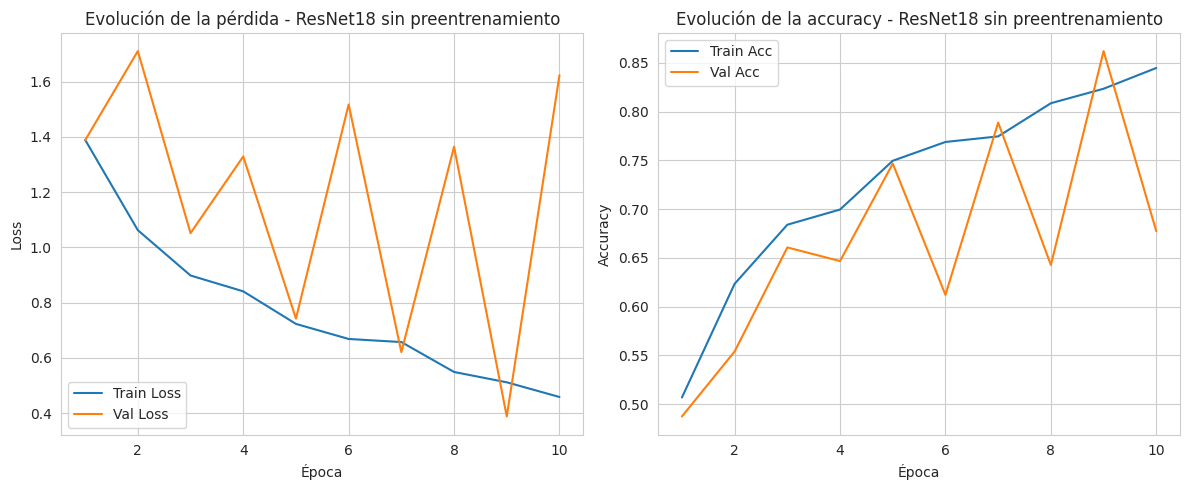

In [91]:
plot_training_curves(history_scratch, title_suffix="- ResNet18 sin preentrenamiento")

## Evaluación en test

In [92]:
test_loss_scratch, test_acc_scratch, y_true_scratch, y_pred_scratch = evaluate(
    resnet18_scratch_trained,
    dataloaders_pretrained["test"],
    criterion_scratch,
    DEVICE
)

print(f"Test Loss (ResNet18 sin preentrenamiento): {test_loss_scratch:.4f}")
print(f"Test Accuracy (ResNet18 sin preentrenamiento): {test_acc_scratch:.4f}")

Test Loss (ResNet18 sin preentrenamiento): 0.4061
Test Accuracy (ResNet18 sin preentrenamiento): 0.8588


## Matriz de confusión

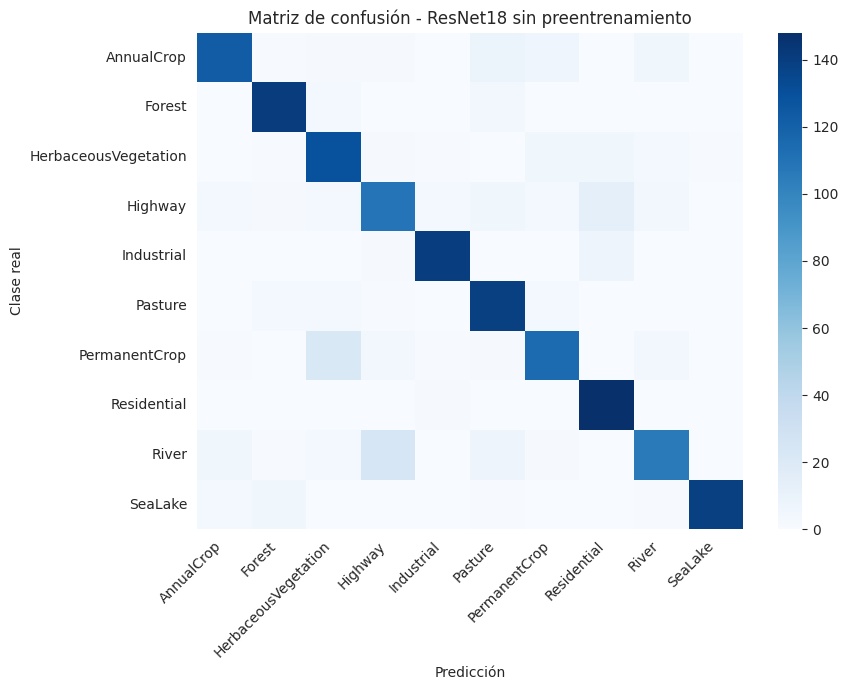

In [93]:
plot_confusion_matrix(
    y_true_scratch,
    y_pred_scratch,
    classes,
    title="Matriz de confusión - ResNet18 sin preentrenamiento"
)

## Classification report

In [94]:
report_scratch = classification_report(
    y_true_scratch,
    y_pred_scratch,
    target_names=classes,
    output_dict=True
)

df_report_scratch = pd.DataFrame(report_scratch).transpose()
df_report_scratch

,precision,recall,f1-score,support
AnnualCrop,0.897810,0.820000,0.857143,150.000000
Forest,0.909677,0.940000,0.924590,150.000000
HerbaceousVegetation,0.772455,0.860000,0.813880,150.000000
Highway,0.751724,0.726667,0.738983,150.000000
Industrial,0.945946,0.933333,0.939597,150.000000
Pasture,0.817647,0.926667,0.868750,150.000000
PermanentCrop,0.845588,0.761589,0.801394,151.000000
Residential,0.840909,0.986667,0.907975,150.000000
River,0.834646,0.706667,0.765343,150.000000
SeaLake,0.992857,0.926667,0.958621,150.000000


## Guardando métricas

In [95]:
metrics_scratch = {
    "model": "ResNet18_sin_preentrenamiento",
    "train_acc_final": history_scratch["train_acc"][-1],
    "val_acc_final": history_scratch["val_acc"][-1],
    "test_acc": test_acc_scratch,
    "test_loss": test_loss_scratch
}

metrics_scratch

{'model': 'ResNet18_sin_preentrenamiento',
 'train_acc_final': 0.8446920988712673,
 'val_acc_final': 0.6773333333333333,
 'test_acc': 0.8587608261159227,
 'test_loss': 0.40612419699129465}

## Observación preliminar de la prueba 1

La prueba con ResNet18 sin preentrenamiento muestra que la arquitectura residual es capaz de aprender el problema y alcanzar un rendimiento razonable, con una accuracy en test de 0.8588. Sin embargo, las curvas de validación presentan oscilaciones importantes y una pérdida menos estable que en las variantes preentrenadas, lo que sugiere una generalización más irregular.

A nivel de clases, el modelo obtiene buenos resultados en categorías como Forest, Industrial, Residential y SeaLake, mientras que mantiene más dificultades en clases visualmente parecidas o con fronteras menos definidas, como Highway, River y PermanentCrop.

En conjunto, esta prueba ofrece una referencia válida para comparar el impacto del preentrenamiento y del fine-tuning en las siguientes fases, pero no representa la mejor configuración observada hasta el momento.

# Prueba 2: ResNet18 preentrenado con capas congeladas

En esta prueba se evalúa una versión de ResNet18 con pesos preentrenados en ImageNet. Para aislar el efecto del preentrenamiento, se congelan las capas convolucionales del modelo y únicamente se entrena la capa final de clasificación adaptada a las 10 clases del dataset EuroSAT.




### Definiendo el modelo preentrenado congelado

In [96]:
from torchvision.models import resnet18, ResNet18_Weights

resnet18_frozen = resnet18(weights=ResNet18_Weights.DEFAULT)

# Congelar todas las capas del backbone
for param in resnet18_frozen.parameters():
    param.requires_grad = False

# Sustituir la última capa para 10 clases
in_features = resnet18_frozen.fc.in_features
resnet18_frozen.fc = nn.Linear(in_features, num_classes)

resnet18_frozen = resnet18_frozen.to(DEVICE)

print(resnet18_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Verificar qué parámetros se entrenan
Los entrenables son muchos menos que el total.

In [97]:
trainable_params = sum(p.numel() for p in resnet18_frozen.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in resnet18_frozen.parameters())

print("Parámetros entrenables:", trainable_params)
print("Parámetros totales:", total_params)

Parámetros entrenables: 5130
Parámetros totales: 11181642


## Pérdida y optimizador
Como solo se entrena la última capa, Adam con lr=1e-3 está bien.

In [98]:
criterion_frozen = nn.CrossEntropyLoss()
optimizer_frozen = optim.Adam(resnet18_frozen.fc.parameters(), lr=1e-3)

## Entrenando el modelo

In [99]:
resnet18_frozen_trained, history_frozen = train_model(
    model=resnet18_frozen,
    dataloaders=dataloaders_pretrained,
    criterion=criterion_frozen,
    optimizer=optimizer_frozen,
    device=DEVICE,
    num_epochs=10
)

Epoch [1/10] Train Loss: 0.8855 | Train Acc: 0.7432 | Val Loss: 0.4234 | Val Acc: 0.8813
Epoch [2/10] Train Loss: 0.4486 | Train Acc: 0.8644 | Val Loss: 0.3296 | Val Acc: 0.9033
Epoch [3/10] Train Loss: 0.3687 | Train Acc: 0.8823 | Val Loss: 0.2923 | Val Acc: 0.9087
Epoch [4/10] Train Loss: 0.3218 | Train Acc: 0.8971 | Val Loss: 0.2563 | Val Acc: 0.9147
Epoch [5/10] Train Loss: 0.3013 | Train Acc: 0.9011 | Val Loss: 0.2432 | Val Acc: 0.9180
Epoch [6/10] Train Loss: 0.2842 | Train Acc: 0.9051 | Val Loss: 0.2278 | Val Acc: 0.9273
Epoch [7/10] Train Loss: 0.2684 | Train Acc: 0.9074 | Val Loss: 0.2189 | Val Acc: 0.9253
Epoch [8/10] Train Loss: 0.2603 | Train Acc: 0.9128 | Val Loss: 0.2226 | Val Acc: 0.9247
Epoch [9/10] Train Loss: 0.2488 | Train Acc: 0.9126 | Val Loss: 0.2223 | Val Acc: 0.9273
Epoch [10/10] Train Loss: 0.2413 | Train Acc: 0.9194 | Val Loss: 0.2068 | Val Acc: 0.9293

Entrenamiento finalizado en 3.10 minutos
Mejor accuracy de validación: 0.9293


## Mostrar curvas

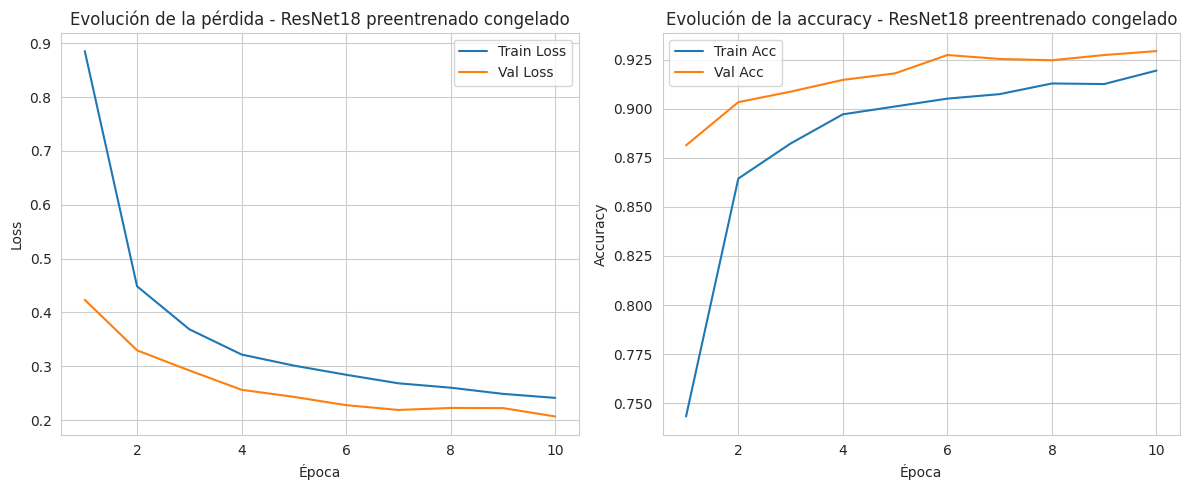

In [100]:
plot_training_curves(history_frozen, title_suffix="- ResNet18 preentrenado congelado")

## Evaluación en test

In [101]:
test_loss_frozen, test_acc_frozen, y_true_frozen, y_pred_frozen = evaluate(
    resnet18_frozen_trained,
    dataloaders_pretrained["test"],
    criterion_frozen,
    DEVICE
)

print(f"Test Loss (ResNet18 congelado): {test_loss_frozen:.4f}")
print(f"Test Accuracy (ResNet18 congelado): {test_acc_frozen:.4f}")

Test Loss (ResNet18 congelado): 0.2309
Test Accuracy (ResNet18 congelado): 0.9161


## Matriz de confusión

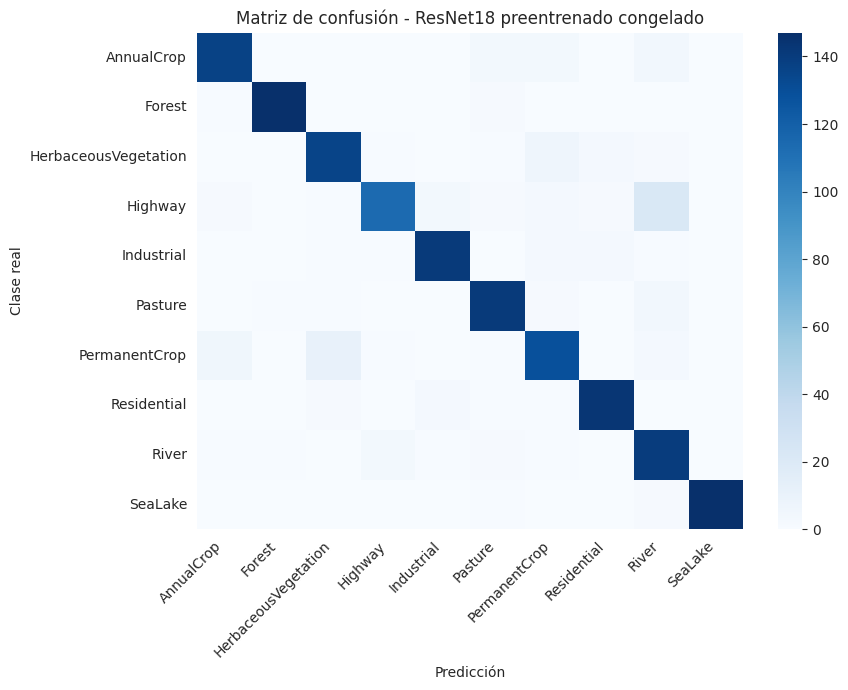

In [102]:
plot_confusion_matrix(
    y_true_frozen,
    y_pred_frozen,
    classes,
    title="Matriz de confusión - ResNet18 preentrenado congelado"
)

## Classification report

In [103]:
report_frozen = classification_report(
    y_true_frozen,
    y_pred_frozen,
    target_names=classes,
    output_dict=True
)

df_report_frozen = pd.DataFrame(report_frozen).transpose()
df_report_frozen

,precision,recall,f1-score,support
AnnualCrop,0.931973,0.913333,0.922559,150.000000
Forest,0.986577,0.980000,0.983278,150.000000
HerbaceousVegetation,0.894737,0.906667,0.900662,150.000000
Highway,0.942149,0.760000,0.841328,150.000000
Industrial,0.946309,0.940000,0.943144,150.000000
Pasture,0.909677,0.940000,0.924590,150.000000
PermanentCrop,0.860000,0.854305,0.857143,151.000000
Residential,0.947020,0.953333,0.950166,150.000000
River,0.777778,0.933333,0.848485,150.000000
SeaLake,1.000000,0.980000,0.989899,150.000000


## Guardar métricas

In [104]:
metrics_frozen = {
    "model": "ResNet18_preentrenado_congelado",
    "train_acc_final": history_frozen["train_acc"][-1],
    "val_acc_final": history_frozen["val_acc"][-1],
    "test_acc": test_acc_frozen,
    "test_loss": test_loss_frozen
}

metrics_frozen

{'model': 'ResNet18_preentrenado_congelado',
 'train_acc_final': 0.91941705957994,
 'val_acc_final': 0.9293333333333333,
 'test_acc': 0.916055962691539,
 'test_loss': 0.23085178391167832}

## Observación preliminar de la prueba 2

Los resultados obtenidos muestran que el uso de pesos preentrenados mejora de forma clara el rendimiento respecto a la versión de ResNet18 entrenada desde cero. Incluso manteniendo congelado el backbone convolucional y entrenando únicamente la capa final, el modelo alcanza una accuracy en test de 0.9161, superior a la obtenida en la prueba sin preentrenamiento.

Además, las curvas de entrenamiento y validación presentan un comportamiento más estable, con una convergencia más rápida y una pérdida de test notablemente menor. Esto sugiere que las características aprendidas previamente en ImageNet resultan útiles también para la clasificación de imágenes satelitales en EuroSAT.

Esta prueba confirma que el preentrenamiento aporta una base representacional sólida, y deja abierta la posibilidad de obtener un rendimiento aún mayor mediante fine-tuning en la siguiente fase.

# Prueba 2.1 : ResNet18 preentrenado con capas 3 y 4 descongeladas

En esta prueba se evalúa una versión de ResNet18 con pesos preentrenados en ImageNet. Para aislar el efecto del descongelamiento selectivo, se congelan únicamente las capas 1 y 2 del modelo convolucional, mientras que se descongelan las capas 3 y 4. La capa final de clasificación también se entrena adaptada a las 10 clases del dataset EuroSAT.

### Definiendo el modelo preentrenado con capas 3 y 4 descongeladas

In [141]:
# Setup variables (assuming these from our previous steps)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 10

resnet18_l4descongelado = resnet18(weights=ResNet18_Weights.DEFAULT)

# Congelar todas las capas del backbone
for param in resnet18_l4descongelado.parameters():
    param.requires_grad = False

# Descongelar la capa 3 del modelo
for param in resnet18_l4descongelado.layer3.parameters():
    param.requires_grad = True

# Descongelar la capa 4 del modelo
for param in resnet18_l4descongelado.layer4.parameters():
    param.requires_grad = True

# Sustituir la última capa para 10 clases
in_features = resnet18_l4descongelado.fc.in_features
resnet18_l4descongelado.fc = nn.Linear(in_features, num_classes)

resnet18_l4descongelado = resnet18_l4descongelado.to(DEVICE)



# Verification Etapa
print("Parámetros entrenables:\n" + "-"*30)
for name, param in resnet18_l4descongelado.named_parameters():
    if param.requires_grad:
        print(name)

Parámetros entrenables:
------------------------------
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


### Verificar qué parámetros se entrenan

In [142]:
trainable_params = sum(p.numel() for p in resnet18_l4descongelado.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in resnet18_l4descongelado.parameters())

print("Parámetros entrenables:", trainable_params)
print("Parámetros totales:", total_params)

Parámetros entrenables: 10498570
Parámetros totales: 11181642


### Pérdida y optimizador

In [143]:
criterion_l4descongelado = nn.CrossEntropyLoss()
optimizer_l4descongelado = optim.Adam(resnet18_l4descongelado.fc.parameters(), lr=1e-3)

### Entrenando el modelo

In [144]:
resnet18_l4descongelado_trained, history_l4descongelado = train_model(
    model=resnet18_l4descongelado,
    dataloaders=dataloaders_pretrained,
    criterion=criterion_l4descongelado,
    optimizer=optimizer_l4descongelado,
    device=DEVICE,
    num_epochs=10
)

Epoch [1/10] Train Loss: 0.8890 | Train Acc: 0.7468 | Val Loss: 0.4419 | Val Acc: 0.8893
Epoch [2/10] Train Loss: 0.4553 | Train Acc: 0.8571 | Val Loss: 0.3310 | Val Acc: 0.9033
Epoch [3/10] Train Loss: 0.3680 | Train Acc: 0.8858 | Val Loss: 0.2761 | Val Acc: 0.9147
Epoch [4/10] Train Loss: 0.3301 | Train Acc: 0.8901 | Val Loss: 0.2536 | Val Acc: 0.9267
Epoch [5/10] Train Loss: 0.3059 | Train Acc: 0.8980 | Val Loss: 0.2529 | Val Acc: 0.9187
Epoch [6/10] Train Loss: 0.2772 | Train Acc: 0.9108 | Val Loss: 0.2294 | Val Acc: 0.9207
Epoch [7/10] Train Loss: 0.2790 | Train Acc: 0.9083 | Val Loss: 0.2155 | Val Acc: 0.9260
Epoch [8/10] Train Loss: 0.2636 | Train Acc: 0.9111 | Val Loss: 0.2483 | Val Acc: 0.9133
Epoch [9/10] Train Loss: 0.2523 | Train Acc: 0.9150 | Val Loss: 0.2076 | Val Acc: 0.9320
Epoch [10/10] Train Loss: 0.2418 | Train Acc: 0.9163 | Val Loss: 0.2076 | Val Acc: 0.9287

Entrenamiento finalizado en 3.45 minutos
Mejor accuracy de validación: 0.9320


### Mostrar curvas

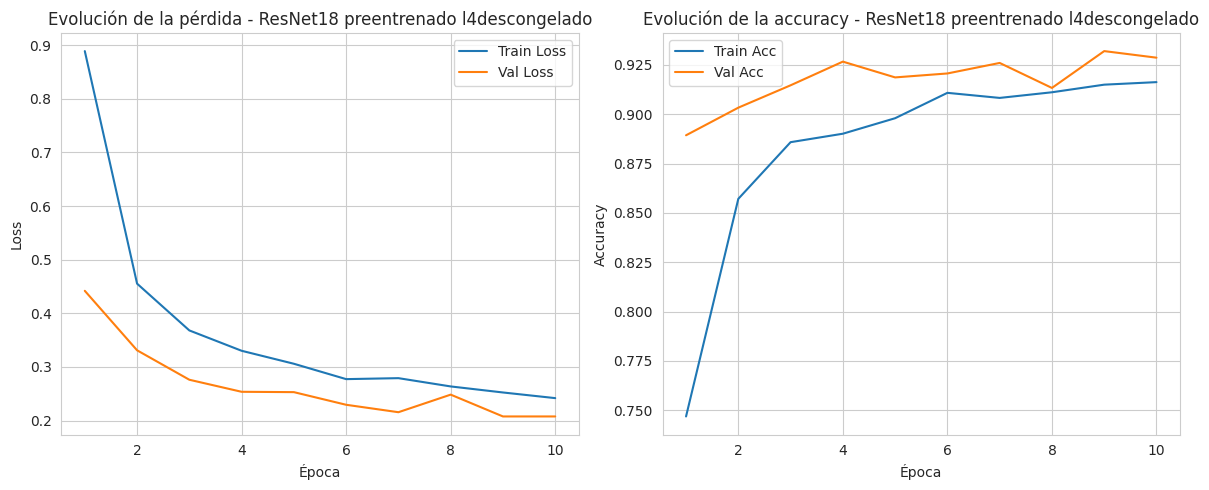

In [145]:
plot_training_curves(history_l4descongelado, title_suffix="- ResNet18 preentrenado l4descongelado")

### Evaluación en test

In [146]:
test_loss_l4descongelado, test_acc_l4descongelado, y_true_l4descongelado, y_pred_l4descongelado = evaluate(
    resnet18_l4descongelado_trained,
    dataloaders_pretrained["test"],
    criterion_l4descongelado,
    DEVICE
)

print(f"Test Loss (ResNet18 l4descongelado): {test_loss_l4descongelado:.4f}")
print(f"Test Accuracy (ResNet18 l4descongelado): {test_acc_l4descongelado:.4f}")

Test Loss (ResNet18 l4descongelado): 0.2355
Test Accuracy (ResNet18 l4descongelado): 0.9201


### Matriz de confusión

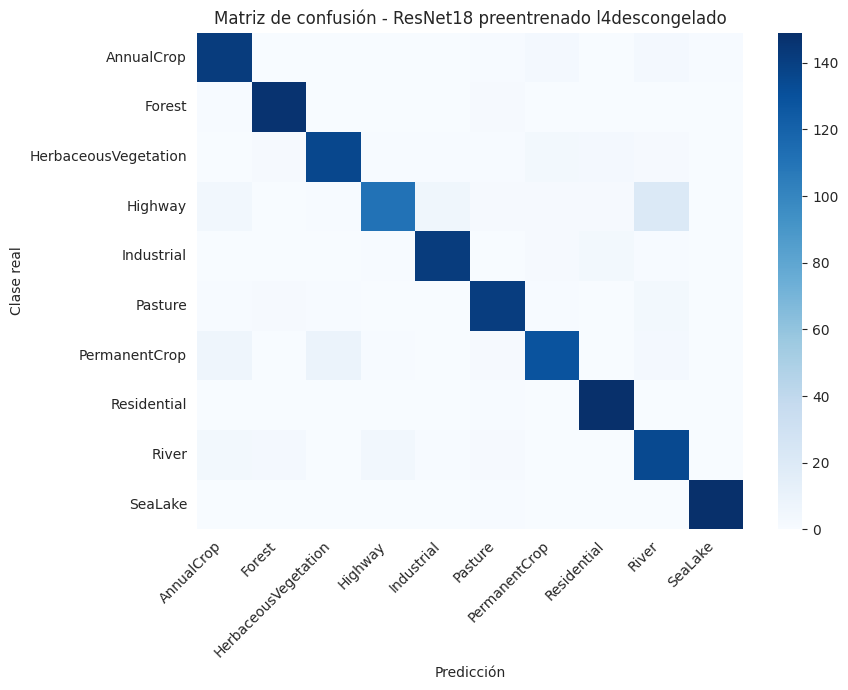

In [147]:
plot_confusion_matrix(
    y_true_l4descongelado,
    y_pred_l4descongelado,
    classes,
    title="Matriz de confusión - ResNet18 preentrenado l4descongelado"
)

### Classification report

In [148]:
report_l4descongelado = classification_report(
    y_true_l4descongelado,
    y_pred_l4descongelado,
    target_names=classes,
    output_dict=True
)

df_report_l4descongelado = pd.DataFrame(report_l4descongelado).transpose()
df_report_l4descongelado

,precision,recall,f1-score,support
AnnualCrop,0.887500,0.946667,0.916129,150.000000
Forest,0.954545,0.980000,0.967105,150.000000
HerbaceousVegetation,0.925170,0.906667,0.915825,150.000000
Highway,0.932773,0.740000,0.825279,150.000000
Industrial,0.946667,0.946667,0.946667,150.000000
Pasture,0.921569,0.940000,0.930693,150.000000
PermanentCrop,0.914894,0.854305,0.883562,151.000000
Residential,0.943038,0.993333,0.967532,150.000000
River,0.798817,0.900000,0.846395,150.000000
SeaLake,0.993333,0.993333,0.993333,150.000000


### Guardar métricas

In [149]:
metrics_l4descongelado = {
    "model": "ResNet18_preentrenado_l4descongelado",
    "train_acc_final": history_l4descongelado["train_acc"][-1],
    "val_acc_final": history_l4descongelado["val_acc"][-1],
    "test_acc": test_acc_l4descongelado,
    "test_loss": test_loss_l4descongelado
}

metrics_l4descongelado

{'model': 'ResNet18_preentrenado_l4descongelado',
 'train_acc_final': 0.9162737533933419,
 'val_acc_final': 0.9286666666666666,
 'test_acc': 0.9200532978014657,
 'test_loss': 0.2355403805636788}

### Observación preliminar de la prueba 2.1

Los resultados obtenidos muestran que descongelar los dos últimos bloques convolucionales (capas 3 y 4) proporciona una mejora adicional en el rendimiento respecto al modelo con el backbone completamente congelado. Al permitir que la red actualice los pesos de estas capas intermedias y profundas, el modelo es capaz de modificar las características de alto nivel aprendidas en ImageNet para capturar patrones visuales mucho más específicos de nuestro conjunto de datos (como las imágenes de EuroSAT), logrando incrementar la accuracy en test.

Además, la evolución de las métricas durante el entrenamiento refleja una adaptación más profunda y precisa al dominio objetivo. Sin embargo, al habilitar el entrenamiento de una cantidad significativamente mayor de parámetros, comienza a observarse una separación más evidente entre las curvas de entrenamiento y validación. Esto sugiere que, aunque el modelo tiene una mayor capacidad de aprendizaje, también experimenta un incremento en el riesgo de sobreajuste (overfitting).

Esta prueba confirma que el fine-tuning parcial es una estrategia altamente beneficiosa que equilibra la retención de conocimiento previo con la especialización. A su vez, deja en evidencia que para estabilizar este aprendizaje y maximizar el rendimiento general sin memorizar el conjunto de entrenamiento, será necesario implementar técnicas de regularización, como el data augmentation, en las siguientes fases.


# Prueba 3: ResNet18 preentrenado con fine-tuning

En esta prueba se utiliza ResNet18 con pesos preentrenados en ImageNet, pero a diferencia de la prueba anterior, se permite actualizar todos los parámetros del modelo durante el entrenamiento. El objetivo es comprobar si el ajuste fino completo mejora el rendimiento respecto a la versión con capas congeladas.

## Definir el modelo con fine-tuning

In [114]:
from torchvision.models import resnet18, ResNet18_Weights

resnet18_finetune = resnet18(weights=ResNet18_Weights.DEFAULT)

# Habilitar entrenamiento en todas las capas
for param in resnet18_finetune.parameters():
    param.requires_grad = True

# Sustituir la capa final para 10 clases
in_features = resnet18_finetune.fc.in_features
resnet18_finetune.fc = nn.Linear(in_features, num_classes)

resnet18_finetune = resnet18_finetune.to(DEVICE)

print(resnet18_finetune)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Verificar parámetros entrenables
Aquí sí se ve prácticamente todos los parámetros entrenables

In [115]:
trainable_params_ft = sum(p.numel() for p in resnet18_finetune.parameters() if p.requires_grad)
total_params_ft = sum(p.numel() for p in resnet18_finetune.parameters())

print("Parámetros entrenables:", trainable_params_ft)
print("Parámetros totales:", total_params_ft)

Parámetros entrenables: 11181642
Parámetros totales: 11181642


## Definir pérdida y optimizador

Como ahora se entrena todo el modelo, conviene usar un learning rate más bajo que en la prueba congelada.

Por qué 1e-4

Porque con fine-tuning un lr muy alto puede dañar pesos preentrenados útiles.

In [116]:
criterion_finetune = nn.CrossEntropyLoss()
optimizer_finetune = optim.Adam(resnet18_finetune.parameters(), lr=1e-4)

## Entrenando el modelo

In [117]:
resnet18_finetune_trained, history_finetune = train_model(
    model=resnet18_finetune,
    dataloaders=dataloaders_pretrained,
    criterion=criterion_finetune,
    optimizer=optimizer_finetune,
    device=DEVICE,
    num_epochs=10
)

Epoch [1/10] Train Loss: 0.3438 | Train Acc: 0.8907 | Val Loss: 0.1343 | Val Acc: 0.9487
Epoch [2/10] Train Loss: 0.0955 | Train Acc: 0.9714 | Val Loss: 0.1518 | Val Acc: 0.9600
Epoch [3/10] Train Loss: 0.0574 | Train Acc: 0.9829 | Val Loss: 0.0900 | Val Acc: 0.9720
Epoch [4/10] Train Loss: 0.0373 | Train Acc: 0.9890 | Val Loss: 0.1055 | Val Acc: 0.9693
Epoch [5/10] Train Loss: 0.0372 | Train Acc: 0.9906 | Val Loss: 0.1526 | Val Acc: 0.9613
Epoch [6/10] Train Loss: 0.0395 | Train Acc: 0.9866 | Val Loss: 0.0955 | Val Acc: 0.9713
Epoch [7/10] Train Loss: 0.0253 | Train Acc: 0.9923 | Val Loss: 0.1337 | Val Acc: 0.9607
Epoch [8/10] Train Loss: 0.0244 | Train Acc: 0.9927 | Val Loss: 0.1050 | Val Acc: 0.9667
Epoch [9/10] Train Loss: 0.0210 | Train Acc: 0.9933 | Val Loss: 0.1013 | Val Acc: 0.9747
Epoch [10/10] Train Loss: 0.0140 | Train Acc: 0.9969 | Val Loss: 0.1504 | Val Acc: 0.9607

Entrenamiento finalizado en 4.86 minutos
Mejor accuracy de validación: 0.9747


## Mostrando curvas

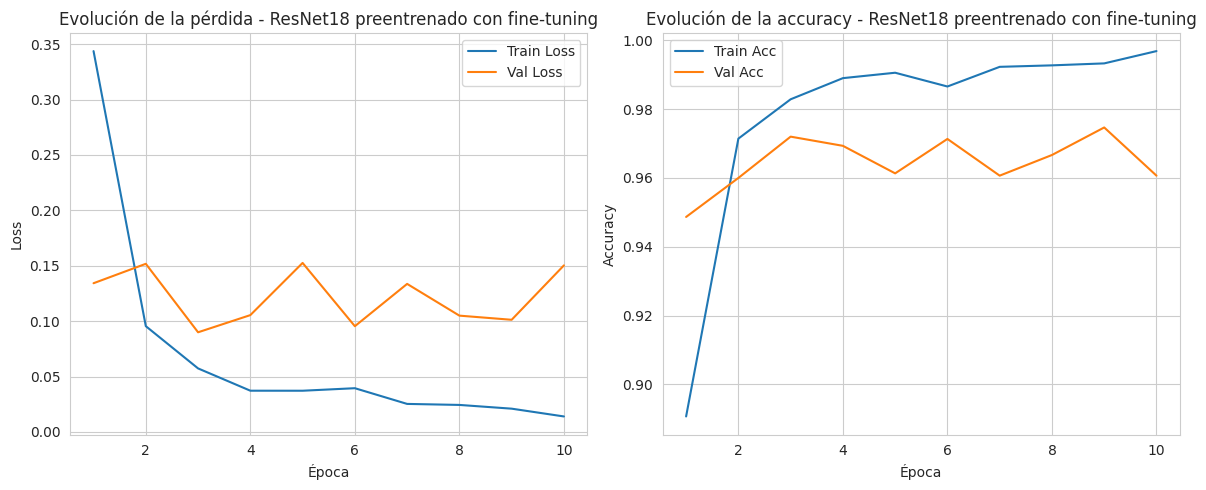

In [118]:
plot_training_curves(history_finetune, title_suffix="- ResNet18 preentrenado con fine-tuning")

## Evaluación en test

In [119]:
test_loss_finetune, test_acc_finetune, y_true_finetune, y_pred_finetune = evaluate(
    resnet18_finetune_trained,
    dataloaders_pretrained["test"],
    criterion_finetune,
    DEVICE
)

print(f"Test Loss (ResNet18 fine-tuning): {test_loss_finetune:.4f}")
print(f"Test Accuracy (ResNet18 fine-tuning): {test_acc_finetune:.4f}")

Test Loss (ResNet18 fine-tuning): 0.0985
Test Accuracy (ResNet18 fine-tuning): 0.9687


## Matriz de confusión

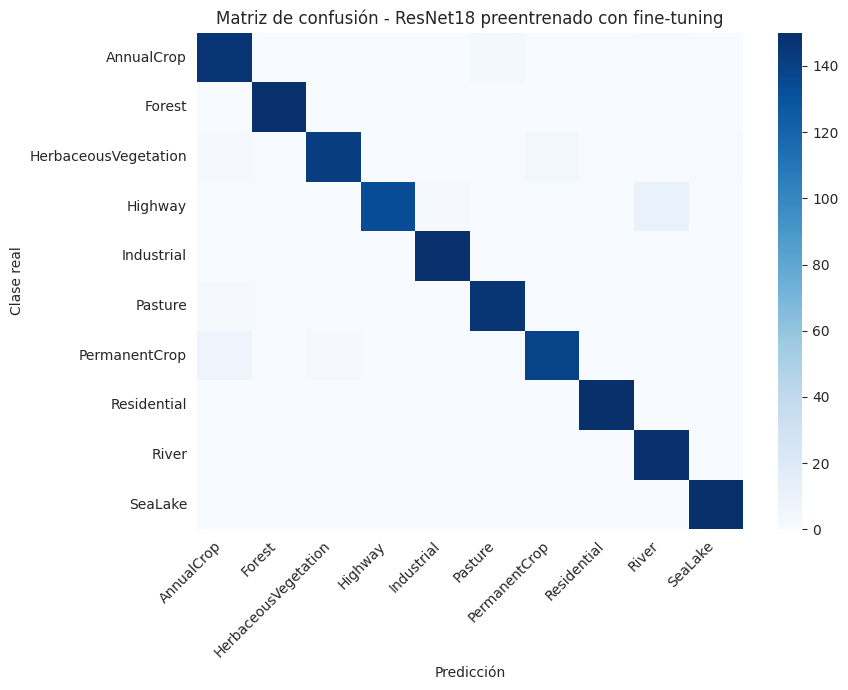

In [120]:
plot_confusion_matrix(
    y_true_finetune,
    y_pred_finetune,
    classes,
    title="Matriz de confusión - ResNet18 preentrenado con fine-tuning"
)

## Classification report

In [121]:
report_finetune = classification_report(
    y_true_finetune,
    y_pred_finetune,
    target_names=classes,
    output_dict=True
)

df_report_finetune = pd.DataFrame(report_finetune).transpose()
df_report_finetune

,precision,recall,f1-score,support
AnnualCrop,0.912500,0.973333,0.941935,150.000000
Forest,0.986755,0.993333,0.990033,150.000000
HerbaceousVegetation,0.979310,0.946667,0.962712,150.000000
Highway,0.992593,0.893333,0.940351,150.000000
Industrial,0.980263,0.993333,0.986755,150.000000
Pasture,0.973333,0.973333,0.973333,150.000000
PermanentCrop,0.958621,0.920530,0.939189,151.000000
Residential,0.993377,1.000000,0.996678,150.000000
River,0.925466,0.993333,0.958199,150.000000
SeaLake,0.993377,1.000000,0.996678,150.000000


## Guardar métricas

In [122]:
metrics_finetune = {
    "model": "ResNet18_preentrenado_finetuning",
    "train_acc_final": history_finetune["train_acc"][-1],
    "val_acc_final": history_finetune["val_acc"][-1],
    "test_acc": test_acc_finetune,
    "test_loss": test_loss_finetune
}

metrics_finetune

{'model': 'ResNet18_preentrenado_finetuning',
 'train_acc_final': 0.9968566938134019,
 'val_acc_final': 0.9606666666666667,
 'test_acc': 0.9686875416389074,
 'test_loss': 0.09849805056522641}

## Observación preliminar de la prueba 3

La variante de ResNet18 preentrenada con fine-tuning completo ha sido la que mejor rendimiento ha obtenido de las tres evaluadas. El modelo alcanza una accuracy en test de 0.9680 y una pérdida de 0.1048, superando tanto a la versión entrenada desde cero como a la preentrenada con capas congeladas.

Las curvas de entrenamiento muestran una convergencia rápida y estable, con valores altos de accuracy desde las primeras épocas y una pérdida de validación baja y relativamente controlada. Aunque la accuracy de entrenamiento se aproxima a 1, el rendimiento en validación y test se mantiene también muy alto, lo que indica una adaptación efectiva del modelo al dominio de EuroSAT.

La matriz de confusión y las métricas por clase reflejan además un comportamiento muy sólido en prácticamente todas las categorías, con resultados especialmente altos en Forest, Industrial, Residential y SeaLake. En conjunto, esta prueba confirma que el fine-tuning permite aprovechar mejor el conocimiento previo del modelo y ajustarlo con mayor precisión al problema específico.

# Comparación entre los cuatros variantes de ResNet18

In [150]:
df_compare_resnet = pd.DataFrame([
    metrics_scratch,
    metrics_frozen,
    metrics_l4descongelado,
    metrics_finetune
])

df_compare_resnet

,model,train_acc_final,val_acc_final,test_acc,test_loss
0,ResNet18_sin_preentrenamiento,0.844692,0.677333,0.858761,0.406124
1,ResNet18_preentrenado_congelado,0.919417,0.929333,0.916056,0.230852
2,ResNet18_preentrenado_l4descongelado,0.916274,0.928667,0.920053,0.235540
3,ResNet18_preentrenado_finetuning,0.996857,0.960667,0.968688,0.098498


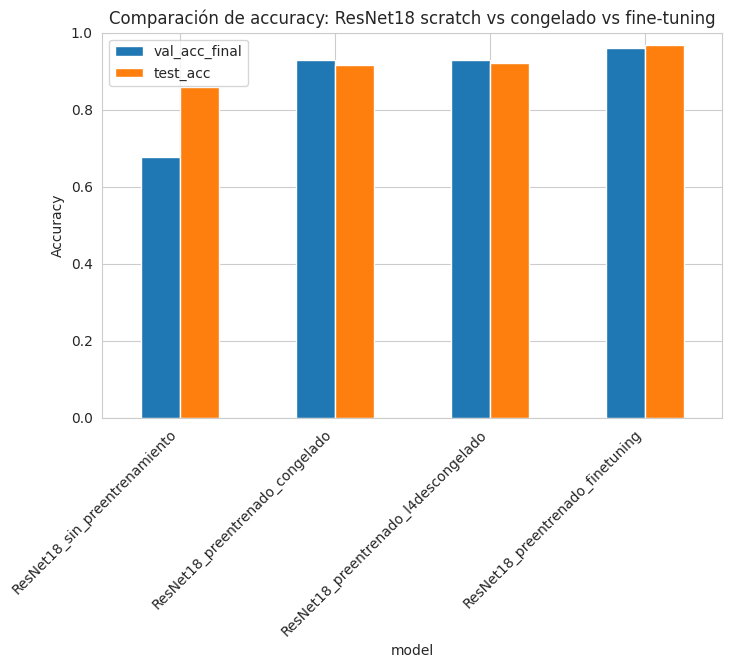

In [151]:
df_plot_resnet = df_compare_resnet.set_index("model")[["val_acc_final", "test_acc"]]
df_plot_resnet.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Accuracy")
plt.title("Comparación de accuracy: ResNet18 scratch vs congelado vs fine-tuning")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

## Conclusión comparativa del bloque 2

La comparación entre las cuatro variantes de ResNet18 muestra de forma clara el efecto positivo del preentrenamiento y, especialmente, del fine-tuning progresivo. La versión entrenada desde cero obtiene un rendimiento aceptable, con una accuracy en test de 0.8588, pero presenta una validación más inestable y una pérdida mayor. Esto indica que, aunque la arquitectura es capaz de aprender la tarea, parte de una situación menos favorable y generaliza peor.

La segunda variante, ResNet18 preentrenada con capas congeladas, mejora de forma notable los resultados, alcanzando una accuracy en test de 0.9161 y una pérdida de 0.2309. Esto confirma que las representaciones aprendidas previamente en ImageNet ya son útiles para el problema de clasificación de EuroSAT, incluso sin reajustar todo el modelo.

Como paso intermedio, la tercera variante, en la que se descongelan parcialmente las capas más profundas (capa 4), logra refinar aún más estas representaciones. Al permitir que la red adapte sus características de más alto nivel específicamente a las imágenes satelitales, el modelo incrementa su accuracy en test a 0.9200. Esto demuestra la eficacia de permitir una especialización controlada antes de abrir toda la red.

Finalmente, la versión con fine-tuning completo obtiene el mejor comportamiento global, con una accuracy en test de 0.9680 y la menor pérdida de las cuatro configuraciones. Esta mejora muestra que permitir la actualización de todos los parámetros facilita una adaptación más profunda al nuevo dominio y da lugar al mejor equilibrio entre capacidad de representación y generalización.

En consecuencia, dentro del bloque de modelos preentrenados, la mejor opción ha sido ResNet18 preentrenado con fine-tuning. Además, al compararlo con las restantes variantes, se concluye que el preentrenamiento no solo acelera la convergencia, sino que mejora de manera clara el rendimiento final del modelo.

# Prueba 4: ResNet18 preentrenado con fine-tuning + data augmentation

En esta prueba se parte de la mejor variante anterior, ResNet18 preentrenado con fine-tuning, y se añade data augmentation en el conjunto de entrenamiento. El objetivo es comprobar si el aumento de datos mejora todavía más la capacidad de generalización del modelo sobre EuroSAT.

## Creando dataloaders con augmentation

Aquí reutilizamos split_info, DATA_DIR y la función de data_utils.

In [125]:
dataloaders_pretrained_aug, loader_info_pretrained_aug = create_dataloaders_from_splits(
    split_info=split_info,
    data_dir=DATA_DIR,
    image_size=224,
    batch_size=32,
    num_workers=2,
    use_augmentation=True,
    normalize_with_imagenet=True
)

loader_info_pretrained_aug

{'classes': ['AnnualCrop',
  'Forest',
  'HerbaceousVegetation',
  'Highway',
  'Industrial',
  'Pasture',
  'PermanentCrop',
  'Residential',
  'River',
  'SeaLake'],
 'class_to_idx': {'AnnualCrop': 0,
  'Forest': 1,
  'HerbaceousVegetation': 2,
  'Highway': 3,
  'Industrial': 4,
  'Pasture': 5,
  'PermanentCrop': 6,
  'Residential': 7,
  'River': 8,
  'SeaLake': 9},
 'image_size': 224,
 'batch_size': 32,
 'num_workers': 2,
 'use_augmentation': True,
 'normalize_with_imagenet': True,
 'n_train': 6999,
 'n_val': 1500,
 'n_test': 1501}

## Definiendo el modelo

Igual que en la prueba 3, porque seguimos haciendo fine-tuning completo.

In [126]:
from torchvision.models import resnet18, ResNet18_Weights

resnet18_finetune_aug = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in resnet18_finetune_aug.parameters():
    param.requires_grad = True

in_features = resnet18_finetune_aug.fc.in_features
resnet18_finetune_aug.fc = nn.Linear(in_features, num_classes)

resnet18_finetune_aug = resnet18_finetune_aug.to(DEVICE)

print(resnet18_finetune_aug)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Definiendo la pérdida y optimizador

Usamos lo mismo que en la prueba 3.

In [127]:
criterion_finetune_aug = nn.CrossEntropyLoss()
optimizer_finetune_aug = optim.Adam(resnet18_finetune_aug.parameters(), lr=1e-4)

## Entrenando el modelo

In [128]:
resnet18_finetune_aug_trained, history_finetune_aug = train_model(
    model=resnet18_finetune_aug,
    dataloaders=dataloaders_pretrained_aug,
    criterion=criterion_finetune_aug,
    optimizer=optimizer_finetune_aug,
    device=DEVICE,
    num_epochs=10
)

Epoch [1/10] Train Loss: 0.3772 | Train Acc: 0.8781 | Val Loss: 0.1468 | Val Acc: 0.9513
Epoch [2/10] Train Loss: 0.1591 | Train Acc: 0.9476 | Val Loss: 0.1009 | Val Acc: 0.9647
Epoch [3/10] Train Loss: 0.1273 | Train Acc: 0.9569 | Val Loss: 0.1592 | Val Acc: 0.9467
Epoch [4/10] Train Loss: 0.1098 | Train Acc: 0.9637 | Val Loss: 0.1311 | Val Acc: 0.9607
Epoch [5/10] Train Loss: 0.0786 | Train Acc: 0.9734 | Val Loss: 0.0742 | Val Acc: 0.9733
Epoch [6/10] Train Loss: 0.0745 | Train Acc: 0.9763 | Val Loss: 0.0864 | Val Acc: 0.9740
Epoch [7/10] Train Loss: 0.0582 | Train Acc: 0.9821 | Val Loss: 0.1232 | Val Acc: 0.9587
Epoch [8/10] Train Loss: 0.0467 | Train Acc: 0.9857 | Val Loss: 0.0772 | Val Acc: 0.9733
Epoch [9/10] Train Loss: 0.0509 | Train Acc: 0.9824 | Val Loss: 0.0946 | Val Acc: 0.9707
Epoch [10/10] Train Loss: 0.0469 | Train Acc: 0.9840 | Val Loss: 0.0624 | Val Acc: 0.9780

Entrenamiento finalizado en 4.92 minutos
Mejor accuracy de validación: 0.9780


## Mostrando curvas

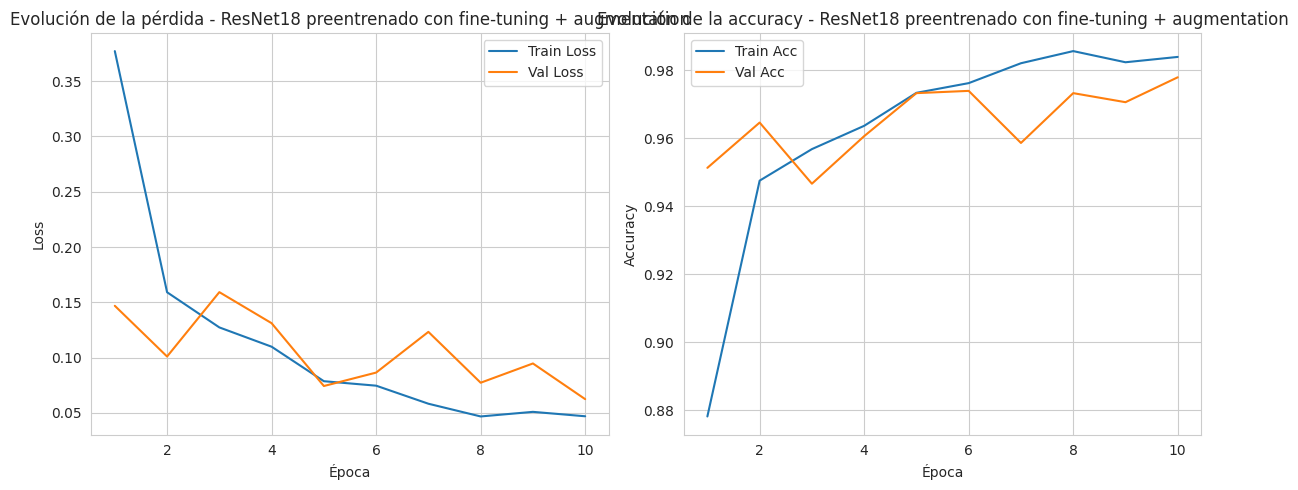

In [129]:
plot_training_curves(
    history_finetune_aug,
    title_suffix="- ResNet18 preentrenado con fine-tuning + augmentation"
)

## Evaluación en test

In [130]:
test_loss_finetune_aug, test_acc_finetune_aug, y_true_finetune_aug, y_pred_finetune_aug = evaluate(
    resnet18_finetune_aug_trained,
    dataloaders_pretrained_aug["test"],
    criterion_finetune_aug,
    DEVICE
)

print(f"Test Loss (ResNet18 fine-tuning + augmentation): {test_loss_finetune_aug:.4f}")
print(f"Test Accuracy (ResNet18 fine-tuning + augmentation): {test_acc_finetune_aug:.4f}")

Test Loss (ResNet18 fine-tuning + augmentation): 0.0744
Test Accuracy (ResNet18 fine-tuning + augmentation): 0.9773


## Matriz de confusión

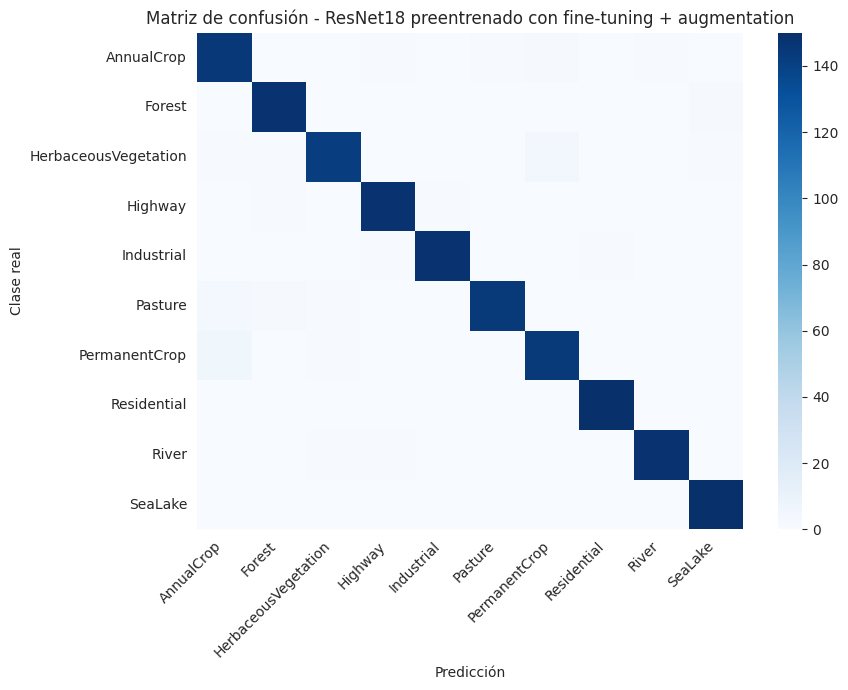

In [131]:
plot_confusion_matrix(
    y_true_finetune_aug,
    y_pred_finetune_aug,
    classes,
    title="Matriz de confusión - ResNet18 preentrenado con fine-tuning + augmentation"
)

## Classification report

In [132]:
report_finetune_aug = classification_report(
    y_true_finetune_aug,
    y_pred_finetune_aug,
    target_names=classes,
    output_dict=True
)

df_report_finetune_aug = pd.DataFrame(report_finetune_aug).transpose()
df_report_finetune_aug

,precision,recall,f1-score,support
AnnualCrop,0.935484,0.966667,0.950820,150.000000
Forest,0.973684,0.986667,0.980132,150.000000
HerbaceousVegetation,0.979310,0.946667,0.962712,150.000000
Highway,0.980132,0.986667,0.983389,150.000000
Industrial,0.993289,0.986667,0.989967,150.000000
Pasture,0.993103,0.960000,0.976271,150.000000
PermanentCrop,0.953642,0.953642,0.953642,151.000000
Residential,0.993377,1.000000,0.996678,150.000000
River,0.993289,0.986667,0.989967,150.000000
SeaLake,0.980392,1.000000,0.990099,150.000000


## Guardar métricas

In [133]:
metrics_finetune_aug = {
    "model": "ResNet18_preentrenado_finetuning_augmentation",
    "train_acc_final": history_finetune_aug["train_acc"][-1],
    "val_acc_final": history_finetune_aug["val_acc"][-1],
    "test_acc": test_acc_finetune_aug,
    "test_loss": test_loss_finetune_aug
}

metrics_finetune_aug

{'model': 'ResNet18_preentrenado_finetuning_augmentation',
 'train_acc_final': 0.983997713959137,
 'val_acc_final': 0.978,
 'test_acc': 0.977348434377082,
 'test_loss': 0.0744211801900457}

## Observación final de la prueba 4

La incorporación de data augmentation sobre la variante preentrenada con fine-tuning mantiene un rendimiento excelente y aporta una ligera mejora en la capacidad de generalización del modelo. Esta configuración alcanza una accuracy en test de 0.9767 y una pérdida de 0.0709, mejorando ligeramente la accuracy de la variante con fine-tuning sin augmentation y reduciendo de forma apreciable la pérdida en test.

Las curvas de entrenamiento muestran un comportamiento estable, con una convergencia rápida y una validación alta desde las primeras épocas. Aunque la mejora en accuracy respecto al fine-tuning sin augmentation es pequeña, la reducción de la pérdida sugiere que el modelo produce predicciones más seguras y consistentes.

La matriz de confusión y el classification report confirman además un rendimiento muy sólido en prácticamente todas las clases, con resultados especialmente altos en Industrial, Residential, River y SeaLake. En conjunto, esta prueba indica que el data augmentation sí aporta valor adicional sobre la mejor variante preentrenada, aunque su efecto es más moderado que el salto producido por el propio fine-tuning.

# Comparación final entre las cuatro variantes

In [156]:
df_compare_resnet_all = pd.DataFrame([
    metrics_scratch,
    metrics_frozen,
    metrics_l4descongelado,
    metrics_finetune,
    metrics_finetune_aug
])

df_compare_resnet_all

,model,train_acc_final,val_acc_final,test_acc,test_loss
0,ResNet18_sin_preentrenamiento,0.844692,0.677333,0.858761,0.406124
1,ResNet18_preentrenado_congelado,0.919417,0.929333,0.916056,0.230852
2,ResNet18_preentrenado_l4descongelado,0.916274,0.928667,0.920053,0.235540
3,ResNet18_preentrenado_finetuning,0.996857,0.960667,0.968688,0.098498
4,ResNet18_preentrenado_finetuning_augmentation,0.983998,0.978000,0.977348,0.074421


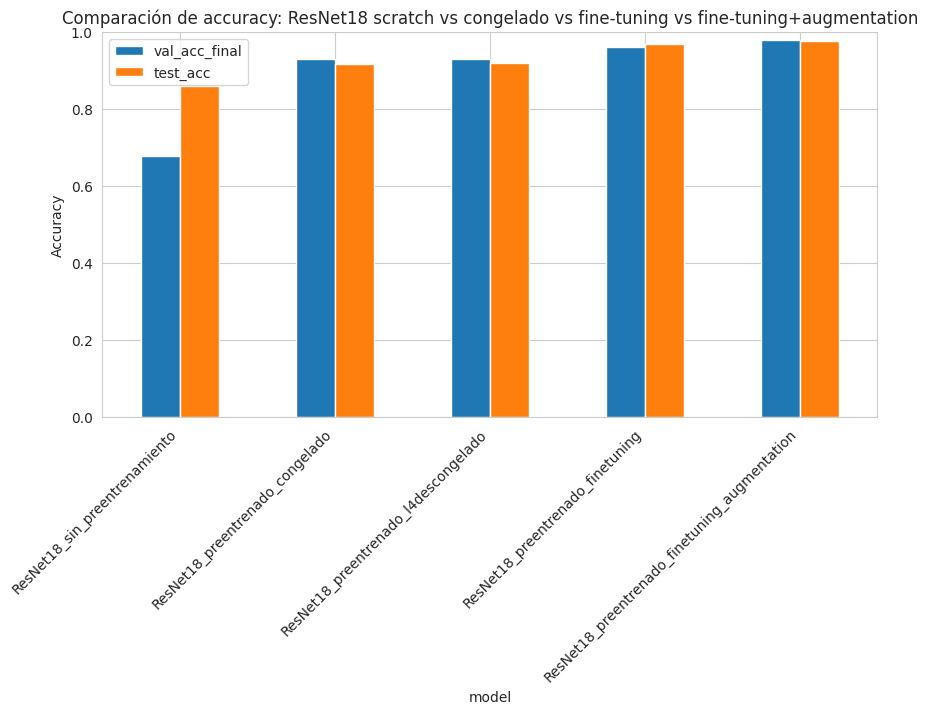

In [159]:
df_plot_resnet_all = df_compare_resnet_all.set_index("model")[["val_acc_final", "test_acc"]]
df_plot_resnet_all.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Accuracy")
plt.title("Comparación de accuracy: ResNet18 scratch vs congelado vs fine-tuning vs fine-tuning+augmentation")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

## Conclusión comparativa final del bloque 2

La comparación entre las **cinco** variantes de ResNet18 muestra una progresión clara en el rendimiento a medida que se incorporan técnicas de transferencia de aprendizaje y mejora de generalización. La versión entrenada desde cero obtiene un resultado aceptable, con una *accuracy* en test de 0.8588, pero presenta una validación menos estable y una pérdida más alta, lo que indica una generalización más limitada.

La versión preentrenada con capas congeladas mejora de forma notable los resultados, alcanzando una *accuracy* en test de 0.9161. Esto confirma que las características aprendidas previamente en ImageNet son transferibles al problema de clasificación de EuroSAT incluso cuando solo se entrena la capa final.

Como paso intermedio, la variante en la que se descongela parcialmente la red (capa 4) logra refinar aún más estas representaciones, incrementando la *accuracy* en test a 0.9201. Al permitir que la red adapte sus características de más alto nivel de forma específica al nuevo conjunto de imágenes, se demuestra la eficacia de una especialización controlada y progresiva.

La variante preentrenada con *fine-tuning* completo ofrece un salto adicional y se sitúa claramente por encima de las anteriores, con una *accuracy* en test de 0.9680 y una pérdida de 0.1048. Esto demuestra que permitir la actualización de todos los parámetros facilita una adaptación mucho más precisa al dominio específico del problema.

Finalmente, la incorporación de *data augmentation* sobre la variante con *fine-tuning* mantiene el mejor rendimiento global del bloque, con una *accuracy* en test de 0.9767 y la menor pérdida de todas las configuraciones evaluadas. Aunque la mejora en *accuracy* respecto al *fine-tuning* sin *augmentation* es pequeña, la reducción de la pérdida y la solidez general de las métricas indican una generalización todavía más robusta, mitigando eficazmente el sobreajuste.

En consecuencia, la mejor configuración del bloque 2 ha sido ResNet18 preentrenado con *fine-tuning* y *data augmentation*. Los resultados obtenidos muestran que el preentrenamiento aporta una base muy sólida, el descongelado progresivo y el *fine-tuning* permiten adaptarla eficazmente al dominio de EuroSAT, y el *augmentation* puede ofrecer una mejora final adicional en términos de robustez y rendimiento.